In [2]:
import numpy as np
import os
import xml.etree.ElementTree as ET
from glob import glob
from tqdm import tqdm
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle, Circle

100%|██████████| 3/3 [00:06<00:00,  2.02s/it]


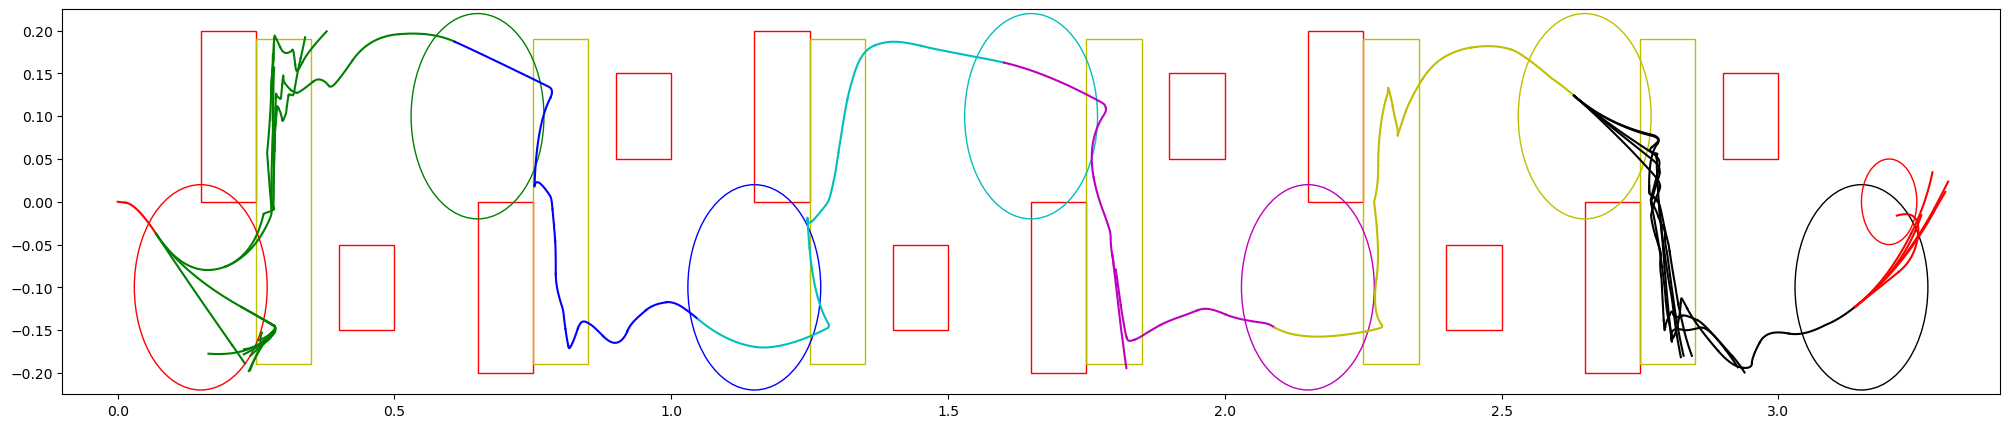

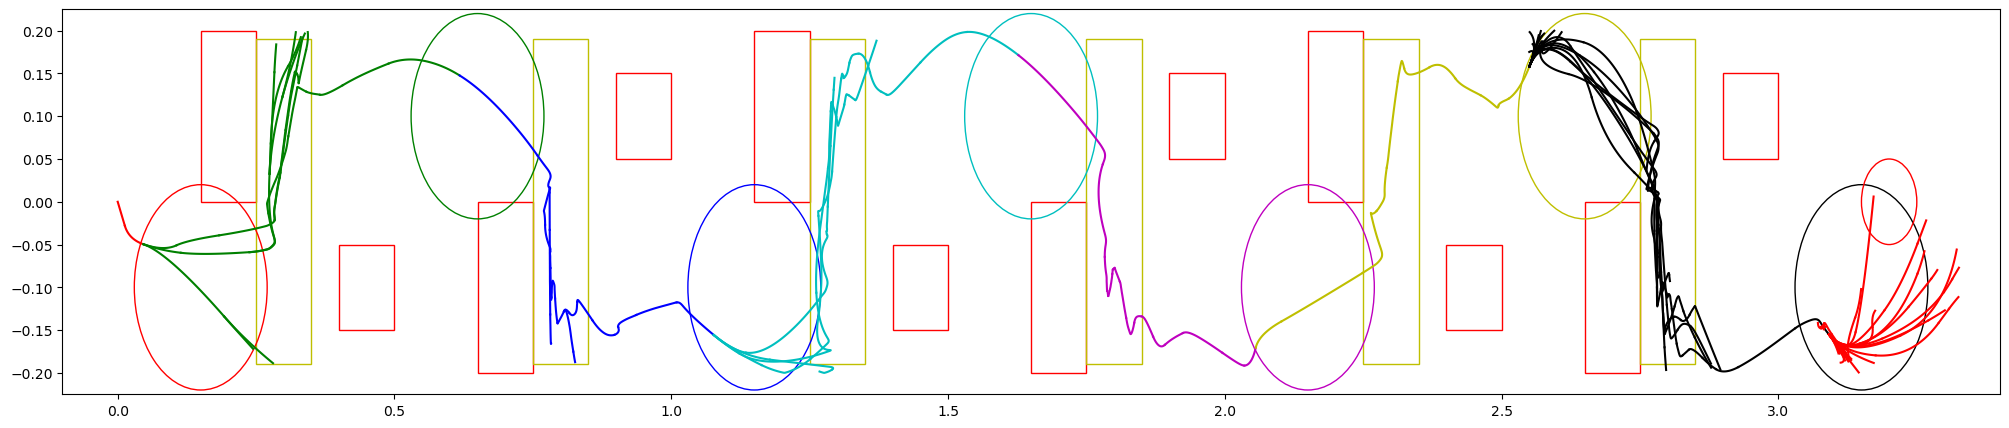

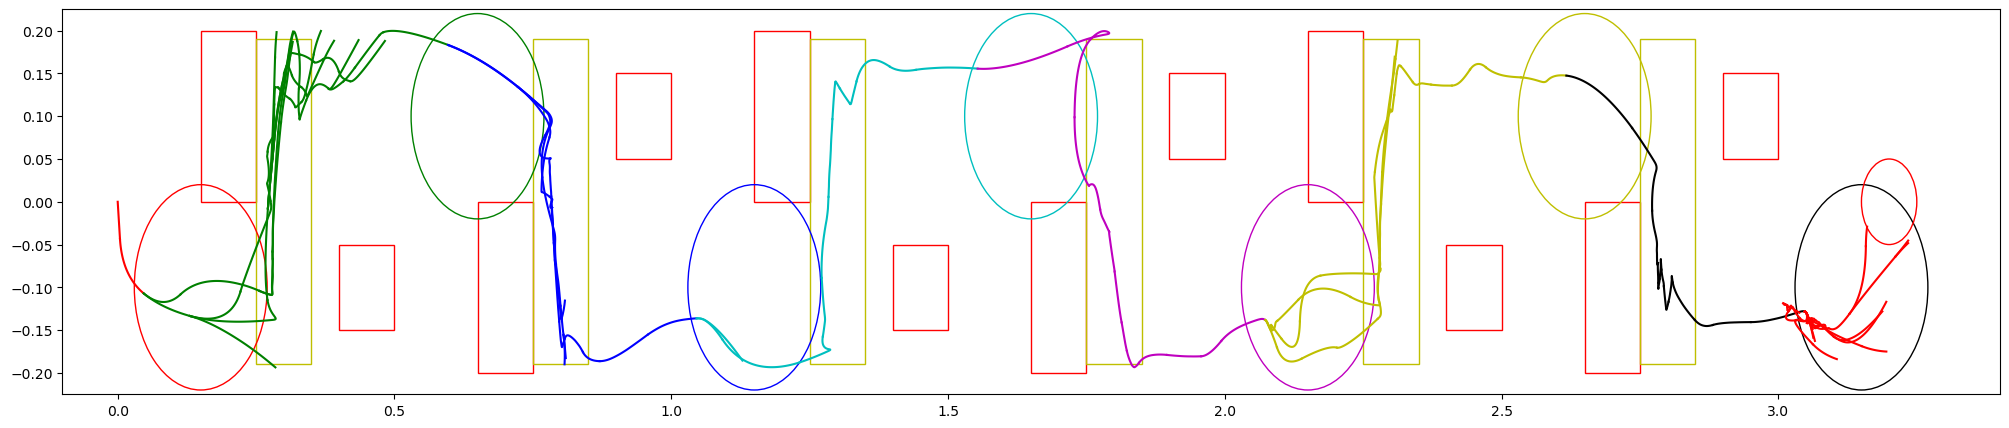

In [5]:
model = "model_object_interactions_6_bottlenecks"
MJ_MODEL = f"/home/dhruv/2024/projects/ml4kp_ktamp/resources/models/push/{model}.xml"
with open(MJ_MODEL, 'r') as file:
    mjx_content = file.read()
root = ET.fromstring(mjx_content)

SUBGOAL_FILE = "/home/dhruv/2024/projects/ml4kp_ktamp/build/object_interactions_6_bottlenecks/subgoals_room2room.txt"
FOLDER = "/home/dhruv/2024/projects/NAMO/out/object_interactions_6_bottlenecks/4Aug/subgoals_room2room_bb/data"
for solution_id_no in tqdm(range(3)):
    SOLUTION_ID = f"solution_{solution_id_no}"
    DESTINATION_FOLDER = os.path.join(FOLDER, SOLUTION_ID, "tree.png")
    solution_folder = os.path.join(FOLDER, SOLUTION_ID, "trees", "*")


    fig, ax = plt.subplots(figsize=(25, 5))

    for body in root.findall('.//body'):
        pos = body.get('pos').split()
        pos = [float(p) for p in pos]
        
        for geom in body.findall('.//geom'):
            geom_type = geom.get('type')
            geom_name = geom.get('name')
            if 'cube' in geom_name or 'wall' in geom_name: 
                edgecolor='r'
                if "movable" in geom_name:
                    edgecolor = 'y'
                
                size = geom.get('size').split()
                size = [float(s) for s in size]
                if geom_type == 'box':
                    # Box size is half-length in each dimension
                    w, h = size[0]*2, size[1]*2
                    rect = Rectangle((pos[0] - w/2, pos[1] - h/2), w, h, edgecolor=edgecolor, facecolor='none')
                    ax.add_patch(rect)

    colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k']
    ctr = -1

    # read subgoals and make circles where each line in the file is x, y, and radius
    with open(SUBGOAL_FILE, 'r') as f:
        for line in f:
            ctr += 1
            if ctr == 0:
                continue
            x, y, r = line.split()
            x, y, r = float(x), float(y), float(r)
            circle = Circle((x, y), r, edgecolor=colors[ctr-1], facecolor='none')
            ax.add_patch(circle)

    ctr += 1
    x, y, r = 3.2, 0.0, 0.05
    circle = Circle((x, y), r, edgecolor=colors[(ctr-1) % len(colors)], facecolor='none')
    ax.add_patch(circle)

    for task_id, folder in enumerate(sorted(glob(solution_folder))):
        points = []
        for i in list(glob(folder+'/*.txt')):
            with open(i, 'r') as f:
                for line in f:
                    points.append(np.array(eval(line.split(': ')[1].strip()))[:2].tolist())
                    # y.append(float(line.split()[1]))
            points = np.array(points)
            ax.plot(points[:, 0], points[:, 1], color=colors[task_id%len(colors)])
            points = []
    ax.set_xlim(-0.1, 3.4)
    ax.set_ylim(-0.225, 0.225)

    fig.savefig(DESTINATION_FOLDER)
    # plt.close(fig)


In [33]:
from PIL import Image
FOLDER = "/home/dhruv/2024/projects/NAMO/out/object_interactions_6_bottlenecks/1Aug/no_subgoals"
solution_id_no = 0
for solution_id_no in range(5):
    SOLUTION_ID = f"solution_{solution_id_no}"
    DESTINATION_FOLDER = os.path.join(FOLDER, 'data', SOLUTION_ID, "tree.png")
    img = Image.open(DESTINATION_FOLDER)
    NEW_DES = os.path.join(FOLDER, 'results')
    if not os.path.exists(NEW_DES): 
        os.makedirs(NEW_DES)
    # write to the same file
    img.save(os.path.join(NEW_DES, f"{SOLUTION_ID}.png"))